## Analyzing business sales data to identify revenue trends, top-selling products, high-value categories, and regional performance.

### 1. Importing necessary libraries

In [4]:
import pandas as pd #for data analysis
import matplotlib.pyplot as plt #for data visualization
import os

### 2. Loading and inspecting the data

##### This is a transnational data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail. The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.

In [5]:
data_frame = pd.read_csv("online_retail.csv", encoding = 'ISO-8859-1') #variable storing the value of the csv file
data_frame.head() #previewing the first part of the data
data_frame.shape #previewing the dimensions of the data

(541909, 8)

### 3. Cleaning the data

In [6]:
#Removing returns (negative quantities)
data_frame = data_frame[data_frame['Quantity'] > 0].copy()
data_frame = data_frame[data_frame['UnitPrice'] > 0].copy()
data_frame = data_frame.dropna(subset=['CustomerID']).copy()

data_frame = data_frame.dropna(subset = ['CustomerID']) #Removing missing customers
data_frame['InvoiceDate'] = pd.to_datetime(data_frame['InvoiceDate']) #Fixing the date format

data_frame = data_frame[data_frame['UnitPrice'] > 0].copy() #accounting for invalid price errors

data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 21.2+ MB


### 4. Feature engineering

In [7]:
#creating revenue
data_frame['Revenue'] = data_frame['Quantity'] * data_frame['UnitPrice']

#extracting time features
data_frame['Month'] = data_frame['InvoiceDate'].dt.to_period('M')
data_frame['Year'] = data_frame['InvoiceDate'].dt.year

data_frame.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2010


### 5. Exploratory core analysis

#### 5.1 Revenue Trend

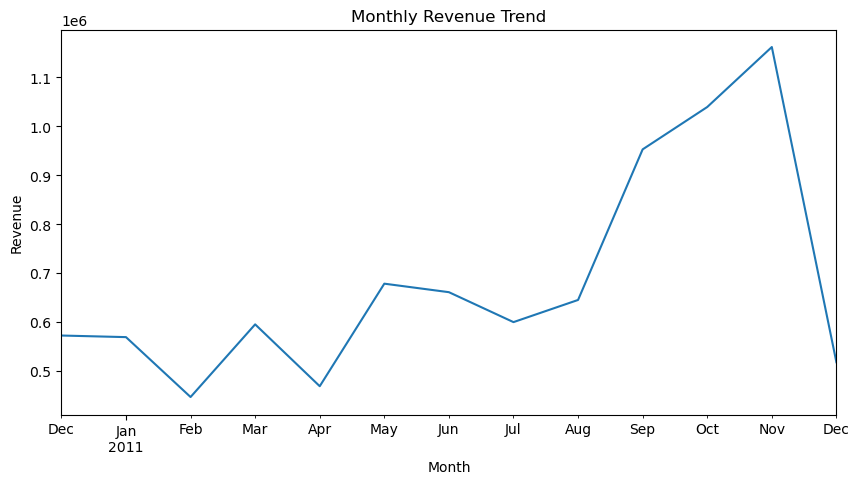

In [8]:
monthly_revenue = data_frame.groupby('Month')['Revenue'].sum()
monthly_revenue.plot(figsize=(10,5), title = "Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

#### 5.2 Top Products

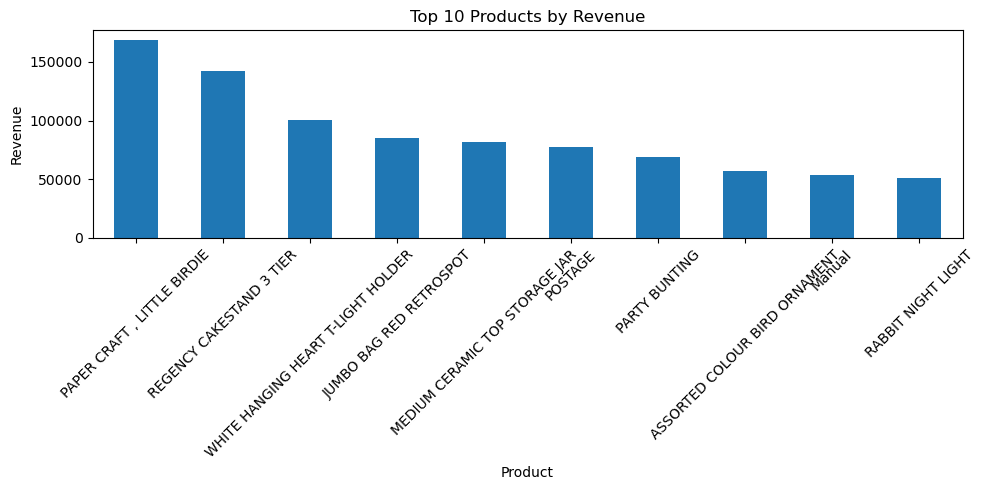

In [9]:
top_products = data_frame.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
top_products.plot(kind = 'bar', figsize = (10,5), title = "Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 5.3 Country Performance

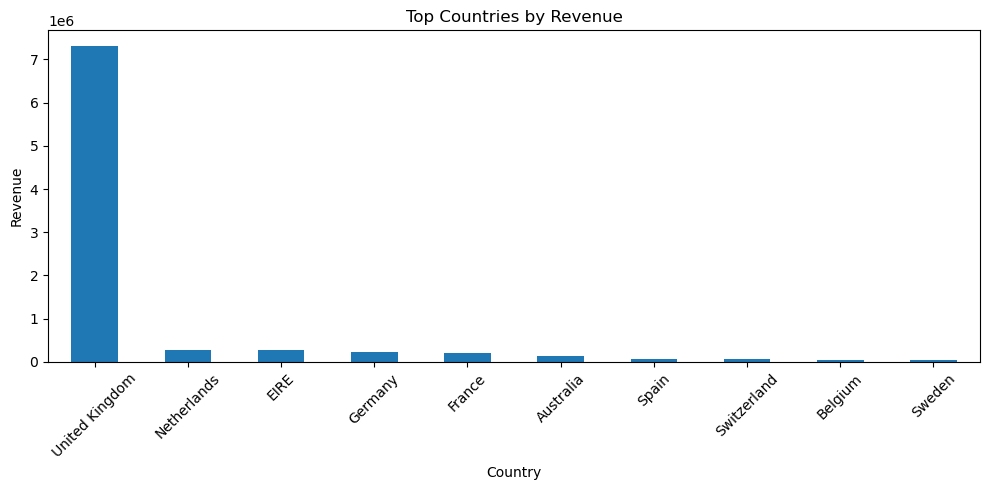

In [10]:
country_revenue = data_frame.groupby('Country')['Revenue'].sum().sort_values(ascending = False)
country_revenue.head(10).plot(kind = 'bar', figsize = (10,5), title = "Top Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### 5.4 Customer Value

In [11]:
customer_revenue = (data_frame.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False))
customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

### 6. Insights and recommendations

### 📈 6.1 Revenue Trends
- Revenue shows a strong upward trend toward the end of the year, peaking in November (~1.16M).
- There is a sharp drop in December (~518K) after the peak.

Insight: 

The business exhibits clear seasonality, with demand building up toward late-year peak periods (likely holiday-driven). The sudden drop in December suggests either post-peak slowdown or incomplete monthly data.

Recommendation:

- Capitalize on Q4 demand (Oct–Nov) with aggressive marketing and inventory planning
- Investigate December drop → determine if it's data cutoff or demand collapse
- Implement year-round demand smoothing strategies

### 🏆 6.2 Product Performance

- Top product: PAPER CRAFT, LITTLE BIRDIE (~168K revenue)
- Top 5 products contribute a significant portion of total revenue

Insight:

Revenue is concentrated among a small group of high-performing products, indicating limited diversification.

Risk:

Heavy reliance on a few products creates revenue vulnerability if demand shifts.

Recommendation:

- Increase promotion of top-performing products
- Analyze why these products succeed (price, demand, seasonality)
- Expand or replicate similar product lines to reduce dependency risk

### 🌍 6.3 Regional Performance

- United Kingdom dominates revenue (~7.3M) by a massive margin
- Next markets (Netherlands, EIRE, Germany, France) are significantly smaller

Insight:

The business is heavily dependent on a single geographic market (UK).

Risk:

Any disruption in the UK market (economic, regulatory, competition) would severely impact total revenue.

Recommendation:

- Expand operations and marketing in high-potential international markets
- Investigate barriers to growth in non-UK regions
- Diversify revenue streams geographically

### 👥 6.4 Customer Analysis

- Top customer (ID: 14646) generated ~280K revenue
- Top 5 customers contribute a substantial share of total revenue

Insight:

Revenue is highly concentrated among a small group of high-value customers.

Risk:

Loss of key customers would result in significant revenue decline.

Recommendation:

- Implement customer retention strategies (loyalty programs, personalized offers)
- Identify characteristics of high-value customers and target similar profiles
- Reduce dependency by broadening the customer base

### 7. Exporting the clean data

In [105]:
data_frame.shape

(397884, 11)

In [106]:
data_frame.to_csv('cleaned_sales_data.csv', index=False)

# Verify immediately
test = pd.read_csv('cleaned_sales_data.csv')
print(test.shape)

(397884, 11)


In [107]:
os.listdir()

['CP-ResearchAssignment.ipynb',
 'FUTURE_DS_01_complete.ipynb',
 'SALES_ANALYSIS.ipynb',
 'Untitled2.ipynb',
 'cleaned_sales_data.csv',
 'online_retail.csv',
 'sales_analysis.ipynb',
 'untitled.py',
 'sqlite.ipynb',
 'r.ipynb',
 'Intro.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']